In [62]:
import pandas as pd

# Load dataset
df = pd.read_csv("credit_scoring_dataset.csv")

# Check rows and columns
print("Dataset Shape:")
print(df.shape)

# Show column names
print("\nColumns:")
print(df.columns.tolist())

# Show data types
print("\nData Types:")
print(df.dtypes)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicates
print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Check target distribution
print("\nCreditworthiness Distribution:")
print(df["Creditworthy"].value_counts())

Dataset Shape:
(2000, 12)

Columns:
['Age', 'Annual_Income', 'Total_Debt', 'Credit_History_Years', 'Payment_History', 'Loan_Count', 'Credit_Utilization_Percent', 'Late_Payments', 'Employment_Years', 'Savings', 'Number_of_Credit_Cards', 'Creditworthy']

Data Types:
Age                             int64
Annual_Income                   int64
Total_Debt                      int64
Credit_History_Years            int64
Payment_History                object
Loan_Count                      int64
Credit_Utilization_Percent    float64
Late_Payments                   int64
Employment_Years                int64
Savings                         int64
Number_of_Credit_Cards          int64
Creditworthy                   object
dtype: object

Missing Values:
Age                           0
Annual_Income                 0
Total_Debt                    0
Credit_History_Years          0
Payment_History               0
Loan_Count                    0
Credit_Utilization_Percent    0
Late_Payments           

In [63]:
# Show basic statistics
df.describe()

,Age,Annual_Income,Total_Debt,Credit_History_Years,Loan_Count,Credit_Utilization_Percent,Late_Payments,Employment_Years,Savings,Number_of_Credit_Cards
count,2000.000000,2.000000e+03,2.000000e+03,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2.000000e+03,2000.000000
mean,43.306000,9.961450e+05,3.869866e+05,15.519500,3.50850,50.083300,1.778500,12.304000,4.059227e+05,3.079500
std,12.931704,4.656704e+05,2.914364e+05,8.607245,2.26108,25.526708,1.346233,8.064062,3.082651e+05,1.982964
min,21.000000,1.801590e+05,6.515000e+03,1.000000,0.00000,5.000000,0.000000,0.000000,6.721000e+03,0.000000
25%,32.000000,6.098058e+05,1.482625e+05,8.000000,2.00000,28.375000,1.000000,5.000000,1.523095e+05,1.000000
50%,44.000000,9.821725e+05,3.105445e+05,16.000000,3.00000,50.150000,2.000000,11.000000,3.271005e+05,3.000000
75%,54.000000,1.390772e+06,5.711590e+05,23.000000,6.00000,71.725000,3.000000,18.000000,5.971060e+05,5.000000
max,65.000000,1.799715e+06,1.315993e+06,30.000000,7.00000,95.000000,8.000000,30.000000,1.387531e+06,6.000000


In [64]:
# Check payment history
print("Payment History:")
print(df["Payment_History"].value_counts())

# Check creditworthiness
print("\nCreditworthiness:")
print(df["Creditworthy"].value_counts())

Payment History:
Payment_History
Good         849
Average      556
Excellent    349
Poor         246
Name: count, dtype: int64

Creditworthiness:
Creditworthy
Yes    1000
No     1000
Name: count, dtype: int64


In [65]:
# Create a copy for preprocessing
data = df.copy()

# Show the new dataset
data.head()

,Age,Annual_Income,Total_Debt,Credit_History_Years,Payment_History,Loan_Count,Credit_Utilization_Percent,Late_Payments,Employment_Years,Savings,Number_of_Credit_Cards,Creditworthy
0,50,1702534,435086,23,Good,0,56.2,1,11,1160479,6,Yes
1,22,1273609,896764,15,Good,4,37.0,2,4,729761,6,No
2,42,1680948,1216927,18,Poor,4,49.4,0,24,228504,0,Yes
3,50,448448,267179,25,Good,2,52.9,1,18,86827,1,Yes
4,56,1183429,500376,1,Good,6,64.0,0,15,633577,6,No


In [66]:
# Convert payment history to numbers
data["Payment_History"] = data["Payment_History"].map({
    "Poor": 0,
    "Average": 1,
    "Good": 2,
    "Excellent": 3
})

# Check the result
data["Payment_History"].head()

0    2
1    2
2    0
3    2
4    2
Name: Payment_History, dtype: int64

In [67]:
# Convert target to numbers
data["Creditworthy"] = data["Creditworthy"].map({
    "No": 0,
    "Yes": 1
})

# Check the result
data["Creditworthy"].head()

0    1
1    0
2    1
3    1
4    0
Name: Creditworthy, dtype: int64

In [68]:
# Check data types
print(data.dtypes)


Age                             int64
Annual_Income                   int64
Total_Debt                      int64
Credit_History_Years            int64
Payment_History                 int64
Loan_Count                      int64
Credit_Utilization_Percent    float64
Late_Payments                   int64
Employment_Years                int64
Savings                         int64
Number_of_Credit_Cards          int64
Creditworthy                    int64
dtype: object


In [69]:
# Check missing values
print(data.isnull().sum())

Age                           0
Annual_Income                 0
Total_Debt                    0
Credit_History_Years          0
Payment_History               0
Loan_Count                    0
Credit_Utilization_Percent    0
Late_Payments                 0
Employment_Years              0
Savings                       0
Number_of_Credit_Cards        0
Creditworthy                  0
dtype: int64


In [70]:
# Separate features and target [x-input ,y-output]
X = data.drop("Creditworthy", axis=1)
y = data["Creditworthy"]

# Check the shapes
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (2000, 11)
Target shape: (2000,)


In [71]:
# Split data into training and testing [80%-train ,20%-test so- t_s=0.2]
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
    # it tells that keep same % of yes & no on test & train
)

# Check the sizes
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (1600, 11)
Testing features: (400, 11)
Training target: (1600,)
Testing target: (400,)


In [72]:
# Train Random Forest model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    # this will creat 100 of decision tree
    # each tree give its own decision
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [73]:
# Make predictions
y_pred = model.predict(X_test)

# Show first 10 predictions
print("Predictions:", y_pred[:10])

Predictions: [0 0 1 0 0 0 1 0 0 1]


In [74]:
# Check model accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.84


In [75]:
# Create confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
# check how many predections are correct & how many are wrong
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[161  39]
 [ 25 175]]


In [76]:
# Show classification report
from sklearn.metrics import classification_report
# check model performance
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.81      0.83       200
           1       0.82      0.88      0.85       200

    accuracy                           0.84       400
   macro avg       0.84      0.84      0.84       400
weighted avg       0.84      0.84      0.84       400



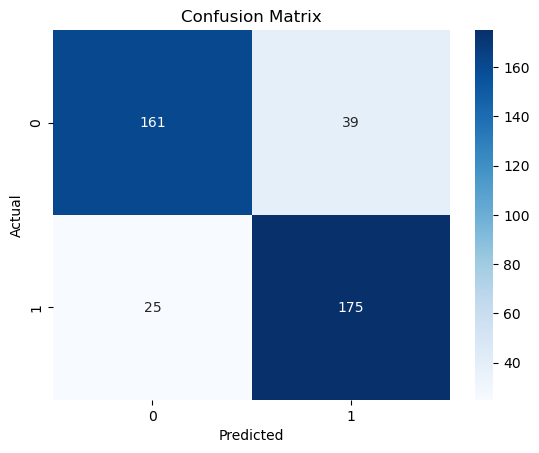

In [77]:
# Visualize confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [78]:
# Check feature importance

importance = model.feature_importances_
# it tell imp feature on what model should predict
# it will give imp-score for each coloum
for feature, score in zip(X.columns, importance):
    print(feature, ":", score)

Age : 0.05156870176722655
Annual_Income : 0.05850400947255431
Total_Debt : 0.06222804008524467
Credit_History_Years : 0.26425878744262415
Payment_History : 0.04865725725371609
Loan_Count : 0.04754748443578617
Credit_Utilization_Percent : 0.23467462773939976
Late_Payments : 0.05290403304427496
Employment_Years : 0.08180342340841668
Savings : 0.06444964802328292
Number_of_Credit_Cards : 0.03340398732747389


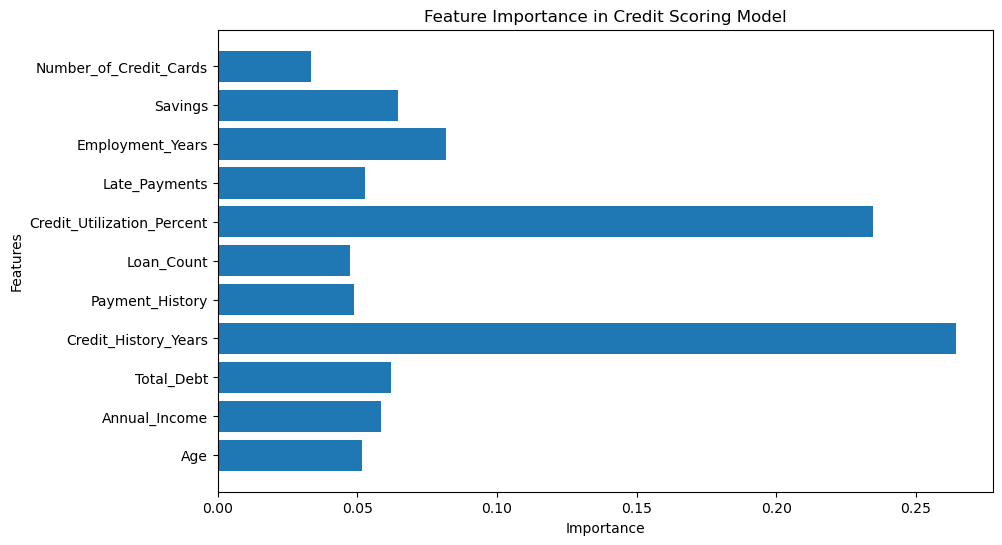

In [79]:
# Visualize feature importance

import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.figure(figsize=(10, 6))
plt.barh(X.columns, importance)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance in Credit Scoring Model")

plt.show()

In [80]:
# Save the trained Random Forest model
# the trained model is saved into file
import joblib

joblib.dump(model, "credit_scoring_model.pkl")
# python pickle file-PKl
print("Model saved successfully!")

Model saved successfully!


In [81]:
# Load the saved Credit Scoring model

import joblib

loaded_model = joblib.load("credit_scoring_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [82]:
# Create a new customer's data

import pandas as pd

new_customer = pd.DataFrame([{
    "Age": 30,
    "Annual_Income": 50000,
    "Total_Debt": 15000,
    "Credit_History_Years": 8,
    "Payment_History": 3,
    "Loan_Count": 2,
    "Credit_Utilization_Percent": 30,
    "Late_Payments": 1,
    "Employment_Years": 5,
    "Savings": 10000,
    "Number_of_Credit_Cards": 2
}])

print(new_customer)

   Age  Annual_Income  Total_Debt  Credit_History_Years  Payment_History  \
0   30          50000       15000                     8                3   

   Loan_Count  Credit_Utilization_Percent  Late_Payments  Employment_Years  \
0           2                          30              1                 5   

   Savings  Number_of_Credit_Cards  
0    10000                       2  


In [83]:
# Predict creditworthiness for the new customer
prediction = loaded_model.predict(new_customer)

print("Prediction:", prediction)

Prediction: [0]


In [84]:
# Show prediction in simple words

if prediction[0] == 1:
    print("Creditworthiness: Creditworthy")
else:
    print("Creditworthiness: Not Creditworthy")

Creditworthiness: Not Creditworthy


In [85]:
# Show prediction probability for the new customer

probability = loaded_model.predict_proba(new_customer)
# here [0][0]-means-[customer1][NO]
# here [0][1]-means-[customer1][YES]
print("Probability of Not Creditworthy:", probability[0][0])
print("Probability of Creditworthy:", probability[0][1])

Probability of Not Creditworthy: 0.63
Probability of Creditworthy: 0.37


In [86]:
# Show final credit scoring result

if prediction[0] == 1:
    print("Final Result: Creditworthy")
    print("Confidence:", round(probability[0][1] * 100, 2), "%")
else:
    print("Final Result: Not Creditworthy")
    print("Confidence:", round(probability[0][0] * 100, 2), "%")

Final Result: Not Creditworthy
Confidence: 63.0 %


In [87]:
# Take customer details as input

def get_customer_input():

    age = int(input("Enter Age: "))
    annual_income = float(input("Enter Annual Income: "))
    total_debt = float(input("Enter Total Debt: "))
    credit_history_years = float(input("Enter Credit History Years: "))
    payment_history = float(input("Enter Payment History (0-3): "))
    loan_count = int(input("Enter Loan Count: "))
    credit_utilization = float(input("Enter Credit Utilization Percent: "))
    late_payments = int(input("Enter Late Payments: "))
    employment_years = float(input("Enter Employment Years: "))
    savings = float(input("Enter Savings: "))
    credit_cards = int(input("Enter Number of Credit Cards: "))

    return pd.DataFrame([{
        "Age": age,
        "Annual_Income": annual_income,
        "Total_Debt": total_debt,
        "Credit_History_Years": credit_history_years,
        "Payment_History": payment_history,
        "Loan_Count": loan_count,
        "Credit_Utilization_Percent": credit_utilization,
        "Late_Payments": late_payments,
        "Employment_Years": employment_years,
        "Savings": savings,
        "Number_of_Credit_Cards": credit_cards
    }])

In [88]:
# Get details of a new customer

new_customer = get_customer_input()

print(new_customer)

Enter Age:  30
Enter Annual Income:  50000
Enter Total Debt:  15000
Enter Credit History Years:  8
Enter Payment History (0-3):  3
Enter Loan Count:  2
Enter Credit Utilization Percent:  30
Enter Late Payments:  1
Enter Employment Years:  5
Enter Savings:  10000
Enter Number of Credit Cards:  2


   Age  Annual_Income  Total_Debt  Credit_History_Years  Payment_History  \
0   30        50000.0     15000.0                   8.0              3.0   

   Loan_Count  Credit_Utilization_Percent  Late_Payments  Employment_Years  \
0           2                        30.0              1               5.0   

   Savings  Number_of_Credit_Cards  
0  10000.0                       2  


In [89]:
# Predict creditworthiness of the new customer

prediction = loaded_model.predict(new_customer)

print("Prediction:", prediction)

Prediction: [0]


In [90]:
# Final Credit Scoring Result

probability = loaded_model.predict_proba(new_customer)

if prediction[0] == 1:
    print("========== CREDIT SCORING RESULT ==========")
    print("Result: Creditworthy")
    print("Confidence:", round(probability[0][1] * 100, 2), "%")
else:
    print("========== CREDIT SCORING RESULT ==========")
    print("Result: Not Creditworthy")
    print("Confidence:", round(probability[0][0] * 100, 2), "%")

========== CREDIT SCORING RESULT ==========
Result: Not Creditworthy
Confidence: 63.0 %


In [91]:
# Calculate ROC-AUC

from sklearn.metrics import roc_auc_score

# Get probability for Creditworthy class
y_probability = model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_probability)

print("ROC-AUC Score:", round(roc_auc, 2))

ROC-AUC Score: 0.92
